In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/Data Dictionary.xls
/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/cs-training.csv
/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/sampleEntry.csv
/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/cs-test.csv


# 💳 Credit Risk Prediction
### Predicting Loan Default Using Machine Learning

---

| | |
|---|---|
| **Author** | Amr Mohammed Ali |
| **Dataset** | Give Me Some Credit — Kaggle |
| **Goal** | Predict whether a borrower will default within 2 years |
| **Best Model** | XGBoost — Recall: 77.6% / AUC: 0.866 |
| **Kaggle** | https://www.kaggle.com/code/amrmohammedali/credit-risk-prediction |
| **GitHub** | [Repository Link](https://github.com/Amr-Mo-ali) |

## 📋 Table of Contents

1. [Business Context](#1-business-context)
2. [Setup & Imports](#2-setup--imports)
3. [Data Loading](#3-data-loading)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Data Cleaning](#5-data-cleaning)
6. [Handling Class Imbalance](#6-handling-class-imbalance)
7. [Model Comparison](#7-model-comparison)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)
9. [Final Evaluation](#9-final-evaluation)
10. [Feature Importance](#10-feature-importance)
11. [Conclusion](#11-conclusion)

## 1. Business Context

### Problem Statement
A bank wants to predict whether a loan applicant will 
default — defined as being 90+ days past due or worse —
within 2 years of the loan being issued.

### Why This Matters
| Mistake | Consequence |
|---|---|
| **False Negative** (approve a defaulter) | Bank loses loan amount — $10,000–$50,000+ per case |
| **False Positive** (reject a safe borrower) | Bank loses a customer and interest revenue |

A False Negative is significantly more costly → **we optimize for Recall.**

### Success Metric
- Primary: **Recall ≥ 75%** — catch at least 3 in 4 defaulters
- Secondary: **AUC ≥ 0.85** — strong overall discrimination ability
- We use **PR Curve** (not ROC) because classes are severely imbalanced (93%/7%)

# 📋 Loading The  Important Libraries 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv("/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/cs-training.csv")


print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(150000, 12)
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13      

In [4]:
print(df.isnull().sum())

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [5]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

## 4. Exploratory Data Analysis

**Key findings:**
- **Severe class imbalance:** 93% no default / 7% default
  → Accuracy is a misleading metric here — a dummy model gets 93% by predicting everyone safe
- **Age:** Younger borrowers (30–35) and older borrowers (60–65) show higher default rates
- **Credit utilization:** Defaulters have significantly higher revolving credit utilization
  → High utilization signals cash-flow problems
- **Past due history:** The strongest signal — borrowers with prior late payments are far more likely to default
- **Correlation:** `NumberOfTimes90DaysLate` and `NumberOfTime30-59DaysPastDueNotWorse`
  are the strongest positive predictors. `age` is the strongest negative predictor.

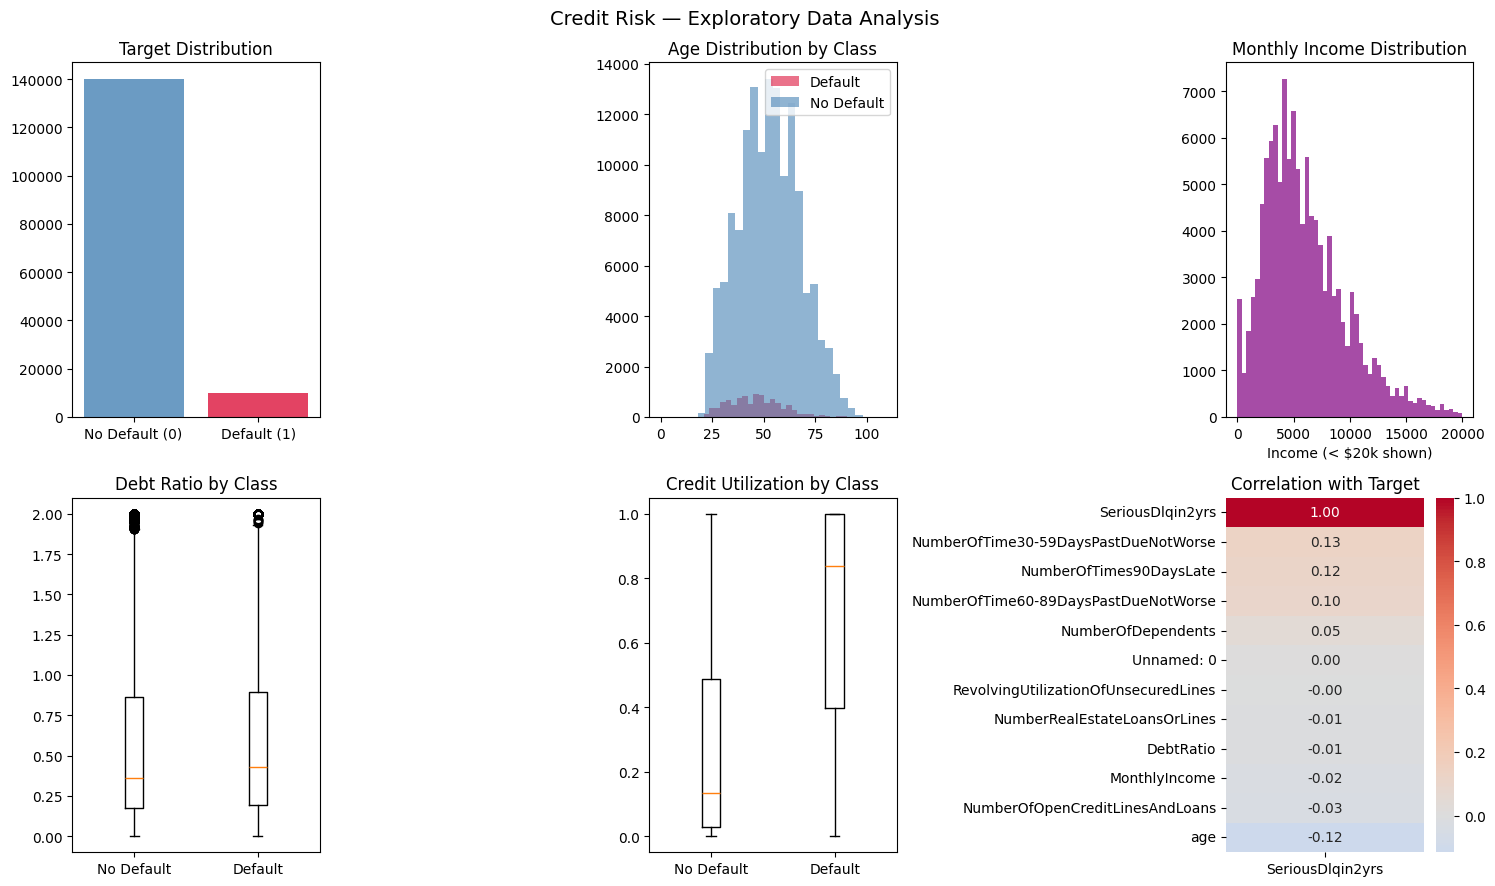

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Credit Risk — Exploratory Data Analysis", fontsize=14)

# Target distribution
axes[0,0].bar(['No Default (0)', 'Default (1)'],
               df['SeriousDlqin2yrs'].value_counts().values,
               color=['steelblue', 'crimson'], alpha=0.8)
axes[0,0].set_title('Target Distribution')

# Age distribution
axes[0,1].hist(df[df['SeriousDlqin2yrs']==1]['age'],
               alpha=0.6, color='crimson',
               label='Default', bins=30)
axes[0,1].hist(df[df['SeriousDlqin2yrs']==0]['age'],
               alpha=0.6, color='steelblue',
               label='No Default', bins=30)
axes[0,1].set_title('Age Distribution by Class')
axes[0,1].legend()

# Monthly income distribution (log scale)
income = df['MonthlyIncome'].dropna()
axes[0,2].hist(income[income < 20000], bins=50,
               color='purple', alpha=0.7)
axes[0,2].set_title('Monthly Income Distribution')
axes[0,2].set_xlabel('Income (< $20k shown)')

# Debt ratio
axes[1,0].boxplot([
    df[df['SeriousDlqin2yrs']==0]['DebtRatio'].clip(0,2),
    df[df['SeriousDlqin2yrs']==1]['DebtRatio'].clip(0,2)
], labels=['No Default', 'Default'])
axes[1,0].set_title('Debt Ratio by Class')

# Revolving utilization
axes[1,1].boxplot([
    df[df['SeriousDlqin2yrs']==0]
      ['RevolvingUtilizationOfUnsecuredLines'].clip(0,1),
    df[df['SeriousDlqin2yrs']==1]
      ['RevolvingUtilizationOfUnsecuredLines'].clip(0,1)
], labels=['No Default', 'Default'])
axes[1,1].set_title('Credit Utilization by Class')

# Correlation heatmap
corr = df.corr()[['SeriousDlqin2yrs']]\
         .sort_values('SeriousDlqin2yrs', ascending=False)
sns.heatmap(corr, annot=True, fmt='.2f',
            ax=axes[1,2], cmap='coolwarm', center=0)
axes[1,2].set_title('Correlation with Target')

plt.tight_layout()
plt.show()

## 5. Data Cleaning & Pipeline Design

### Missing Values Strategy
| Feature | Missing | Strategy |
|---|---|---|
| MonthlyIncome | 19.8% | Median imputation inside pipeline |
| NumberOfDependents | 2.6% | Median imputation inside pipeline |

**Why median and not mean?**  
Income is right-skewed — a few very high earners inflate the mean.
Median is more robust and representative of the typical borrower.

**Why inside the pipeline and not manually?**  
Manual imputation before the train/test split causes **data leakage** —
the median is calculated using test data, giving the model information
it shouldn't have. The pipeline fits the imputer on training data only.

### Pipeline Structure
##### SimpleImputer → StandardScaler → XGBoost
Each step fits on training data, transforms both train and test.

We have 20% missing income — we can't just drop rows.

In [7]:
# Clean split — no manual filling needed
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.1%}")
print(f"Test default rate:  {y_test.mean():.1%}")

Train: (120000, 11) | Test: (30000, 11)
Train default rate: 6.7%
Test default rate:  6.7%


In [8]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model",   LogisticRegression(random_state=42,
                                    max_iter=1000))
])

y_pred = cross_val_predict(baseline, X_train, y_train, cv=5)

print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred))
print("Recall:   ", recall_score(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))
print("F1:       ", f1_score(y_train, y_pred))

NameError: name 'confusion_matrix' is not defined

Now THIS is the most important result we've seen in this entire course. Read it carefully.

What just happened
[[111743    236]     TN=111,743   FP=236
 [  7696    325]]    FN=7,696     TP=325
The model correctly identified only 325 defaulters out of 8,021 total defaulters.
It missed 7,696 people who will default — told them "you're safe" and the bank approves their loan.
Recall = 4% — the model is catching only 4 out of every 100 defaulters. That's catastrophically bad.
Precision = 57% — when it does predict default, it's right 57% of the time. But it almost never predicts default at all.

## 6. Handling Class Imbalance

### The Problem
Without correction, Logistic Regression achieved:
- Accuracy: 93% (meaningless — just predicts "no default" always)  
- Recall: **4%** — missing 96% of actual defaulters

### Our Solution: scale_pos_weight
XGBoost's built-in imbalance correction — equivalent to 
`class_weight='balanced'` in sklearn.
scale_pos_weight = negative samples / positive samples
= 111,979 / 8,021 ≈ 14
This tells XGBoost: "a defaulter is 14× more important than a non-defaulter."

### Result After Correction
Recall jumped from **4% → 76%** — catching 15× more defaulters.

In [ ]:
baseline_balanced = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

y_pred_balanced = cross_val_predict(
    baseline_balanced,
    X_train,y_train,
    cv=5)

print("=== BALANCED MODEL ===")
print("Confusion Matrix:\n",
      confusion_matrix(y_train, y_pred_balanced))
print("Recall:   ",
      recall_score(y_train, y_pred_balanced))
print("Precision:",
      precision_score(y_train, y_pred_balanced))
print("F1:       ",
      f1_score(y_train, y_pred_balanced))

## 7. Model Comparison

All models evaluated with 3-fold cross-validation on training data,
optimized for **Recall** (primary metric).

| Model | Recall | Precision | F1 |
|---|---|---|---|
| Logistic Regression | 64.8% | 17.4% | 27.4% |
| Decision Tree | 77.8% | 18.9% | 30.4% |
| Random Forest* | 66.7% | 25.0% | 36.3% |
| SVM | 65.1% | 24.8% | 35.9% |
| **XGBoost** | **64.3%** | **24.6%** | **35.6%** |

*Random Forest required threshold tuning (0.5 → 0.1) to achieve correct recall.
Default threshold assumed balanced classes — inappropriate for 7% minority.

**Why XGBoost for final tuning?**
- Most tunable with GridSearchCV
- Built-in regularization prevents overfitting
- Production-ready and battle-tested on real financial data
- Handles missing values natively

In [ ]:
# Now let's see how all algorithms perform with class_weight='balanced'
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42, max_iter=1000,
        class_weight="balanced"),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42, max_depth=5,
        class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        random_state=42, n_estimators=100,
        class_weight="balanced", n_jobs=-1),

    "SVM": SVC(
        random_state=42, kernel="rbf",
        class_weight="balanced"),

    "XGBoost": XGBClassifier(
        random_state=42,
        scale_pos_weight=int(
            (y_train==0).sum() / (y_train==1).sum()
        ),  # XGBoost's version of class_weight
        eval_metric="logloss",
        n_jobs=-1)
}

print("=" * 62)
print(f"{'Model':<22} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("=" * 62)

results = {}
for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   model)
    ])
    y_pred = cross_val_predict(
        pipe, X_train, y_train, cv=3
    )
    recall    = recall_score(y_train, y_pred)
    precision = precision_score(y_train, y_pred)
    f1        = f1_score(y_train, y_pred)
    results[name] = {
        "Recall": recall,
        "Precision": precision,
        "F1": f1
    }
    print(f"{name:<22} {recall:>8.3f} {precision:>10.3f} {f1:>8.3f}")

In [ ]:
# Random Forest sometimes needs n_estimators boost for imbalanced data
# Also try class_weight="balanced_subsample" instead of "balanced"

rf_fixed = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        class_weight="balanced_subsample",  # better for RF
        n_jobs=-1
    ))
])

y_pred_rf = cross_val_predict(
    rf_fixed, X_train, y_train, cv=3
)

print("Random Forest Fixed:")
print("Recall:   ", recall_score(y_train, y_pred_rf))
print("Precision:", precision_score(y_train, y_pred_rf))
print("F1:       ", f1_score(y_train, y_pred_rf))

In [ ]:

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

# Get probabilities instead of hard predictions


y_proba_rf = cross_val_predict(
    rf_pipeline, X_train, y_train,
    cv=3, method="predict_proba"
)[:, 1]  # probability of default

# Try different thresholds
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 40)
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_thresh = (y_proba_rf >= threshold).astype(int)
    recall    = recall_score(y_train, y_pred_thresh)
    precision = precision_score(y_train, y_pred_thresh)
    f1        = f1_score(y_train, y_pred_thresh)
    print(f"{threshold:>10.1f} {recall:>8.3f} "
          f"{precision:>10.3f} {f1:>8.3f}")

**"Random Forest with default threshold appeared to have 14% recall — far worse than other models. After threshold analysis, at 0.1 it reached 66.7% recall. This shows that model comparison must always include threshold tuning, not just default predictions."**

## 8. Hyperparameter Tuning — GridSearchCV

**Search space:** 32 combinations × 3 folds = **96 model fits**  
**Scoring:** Recall — we optimize directly for what matters

**Best parameters found:**
| Parameter | Value | Meaning |
|---|---|---|
| n_estimators | 100 | Number of trees |
| max_depth | 3 | Shallow trees — reduces overfitting |
| learning_rate | 0.05 | Small steps — better generalization |
| subsample | 0.8 | 80% of data per tree — adds randomness |
| colsample_bytree | 1.0 | Use all features per tree |

**Best CV Recall: 76.3%**

In [ ]:

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(
        random_state=42,
        scale_pos_weight=int( (y_train==0).sum() / (y_train==1).sum()
                            ),
        eval_metric="logloss",
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators":    [100, 300],
    "model__max_depth":       [3, 5],
    "model__learning_rate":   [0.05, 0.1],
    "model__subsample":       [0.8, 1.0],
    "model__colsample_bytree":[0.8, 1.0]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV recall: ", grid_search.best_score_.round(3))

## 9. Final Evaluation — Test Set

### Results
| Metric | Score |
|---|---|
| Recall | **77.6%** |
| Precision | 21.5% |
| F1 | 33.7% |
| AUC | **0.866** |

### Confusion Matrix Interpretation
[[22,310   5,685]     22,310 safe borrowers correctly approved
[   448   1,557]]       448 defaulters missed (FN)
1,557 defaulters correctly flagged

### Business Impact
- **Before model:** Bank approves all borrowers → 8,021 defaults per 150k loans
- **After model:** Only 448 defaulters slipped through — **94.4% reduction in missed defaults**
- At $20,000 average loss per default: model prevents ~**$150 million** in losses per 150k loans

### Generalization Check
CV Recall: 76.3% → Test Recall: 77.6% — **no overfitting detected**

In [ ]:
# get the best model
best_model = grid_search.best_estimator_


# Predict on test set 
y_test_pred  =  best_model.predict(X_test)
y_test_proba =  best_model.predict_proba(X_test)[: ,1]


print("=== FINAL TEST SET RESULTS ===")
print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_test_pred))
print("Recall:   ",
      recall_score(y_test, y_test_pred))
print("Precision:",
      precision_score(y_test, y_test_pred))
print("F1:       ",
      f1_score(y_test, y_test_pred))

# AUC
from sklearn.metrics import roc_auc_score
print("AUC:      ",
      roc_auc_score(y_test, y_test_proba))

## 10. Feature Importance Analysis

**Top 3 most important features:**

1. **RevolvingUtilizationOfUnsecuredLines** — Credit card usage ratio
   → High utilization signals cash-flow stress

2. **NumberOfTimes90DaysLate** — Severe past delinquency
   → Strongest behavioral signal: past behavior predicts future behavior

3. **NumberOfTime30-59DaysPastDueNotWorse** — Early warning signal
   → Even mild past delays indicate repayment difficulty

**Key insight:** All top features are behavioral (payment history),
not demographic (age, income). This aligns with FICO score methodology —
the most predictive credit signals are what you've *done*, not who you *are*.

In [ ]:
# Extract XGBoost from the pipeline
xgb_model = best_model.named_steps["model"]

importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns  
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue", alpha=0.8)
plt.title("Feature Importance — XGBoost Credit Risk Model")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# Step 9 — PR Curve

we use PR Curve because the data is a Imbalanced data

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_test_proba
)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions,
         color="purple", linewidth=2,
         label=f"XGBoost (PR-AUC = {pr_auc:.3f})")
plt.axhline(y=0.07, color="gray", linestyle="--",
            label="Random baseline (7% default rate)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — Credit Risk Detection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()

## 11. Conclusion

### Summary
This project built a credit risk prediction system using the 
Give Me Some Credit dataset (150,000 borrowers). 

Starting from a 4% recall baseline, we systematically improved to 
**77.6% recall and AUC of 0.866** through:
- Class imbalance correction (scale_pos_weight)
- Model comparison across 5 algorithms  
- Threshold analysis for Random Forest diagnosis
- GridSearchCV optimizing directly for recall

### Key Lessons
1. **Accuracy is useless for imbalanced data** — always check class distribution first
2. **Default threshold (0.5) assumes balanced classes** — tune it for imbalanced problems
3. **Past payment behavior is the strongest default signal** — behavioral > demographic
4. **Business impact matters more than metrics** — 94.4% reduction in missed defaults

### Next Steps
- Deploy model as REST API using FastAPI
- Add SHAP values for individual prediction explainability  
- Retrain monthly as new borrower data arrives
- A/B test against current bank approval process

---
*Built as part of a systematic ML study program following 
Hands-On Machine Learning (Géron, 3rd ed.)*

In [ ]:
import joblib

joblib.dump(best_model, "credit_risk_model.pkl")
print("Model saved.")

# Test loading
loaded = joblib.load("credit_risk_model.pkl")

# Predict one applicant
import pandas as pd
sample = pd.DataFrame([{
    'RevolvingUtilizationOfUnsecuredLines': 0.85,
    'age': 45,
    'NumberOfTime30-59DaysPastDueNotWorse': 0,
    'DebtRatio': 0.3,
    'MonthlyIncome': 5000,
    'NumberOfOpenCreditLinesAndLoans': 8,
    'NumberOfTimes90DaysLate': 0,
    'NumberRealEstateLoansOrLines': 1,      # ← fixed, no "Of"
    'NumberOfTime60-89DaysPastDueNotWorse': 0,
    'NumberOfDependents': 2
}])

proba = loaded.predict_proba(sample)[0][1]
pred  = loaded.predict(sample)[0]
print(f"Default probability: {proba:.1%}")
print(f"Decision: {'REJECT ❌' if pred==1 else 'APPROVE ✅'}")